# Customer Churn Prediction
**Solomon moses**

This notebook covers: data preparation, EDA & hypothesis testing, feature selection, model building & evaluation, and export of the best model for Streamlit deployment.

## 1. Objectives

- Understand the drivers of customer churn in the Telco dataset
- Clean and prepare the data for modeling
- Explore relationships between customer attributes and churn
- Select statistically significant features
- Build and compare multiple classification models
- Recommend the best-performing model for deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)
import joblib

sns.set_style('whitegrid')
%matplotlib inline

## 2. Data Preparation

The uploaded dataset is the extended IBM Telco file (33 columns). We drop columns that are either
constant/irrelevant, geographic detail beyond the project brief, or would leak the target
(`Churn Score`, `CLTV`, `Churn Reason`, `Churn Label`).

In [2]:
df = pd.read_excel('/mnt/user-data/uploads/Telco_customer_churn.xlsx')
print("Raw shape:", df.shape)
df.head()

Raw shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
drop_cols = ['Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long',
             'Latitude', 'Longitude', 'Churn Score', 'CLTV',
             'Churn Label', 'Churn Reason']
df = df.drop(columns=drop_cols)
df = df.rename(columns={'Churn Value': 'Churn'})
print("Shape after dropping irrelevant/leaky columns:", df.shape)

Shape after dropping irrelevant/leaky columns: (7043, 21)


In [4]:
# Fix Total Charges: blank strings for tenure=0 customers -> coerce to numeric, fill 0
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print("Nulls created by coercion:", df['Total Charges'].isnull().sum())

zero_tenure_mask = (df['Tenure Months'] == 0) & (df['Total Charges'].isnull())
print("All are zero-tenure customers:", zero_tenure_mask.sum() == df['Total Charges'].isnull().sum())
df['Total Charges'] = df['Total Charges'].fillna(0)

Nulls created by coercion: 11
All are zero-tenure customers: True


In [5]:
# Duplicates
print("Duplicate CustomerIDs:", df.duplicated(subset='CustomerID').sum())
df = df.drop_duplicates(subset='CustomerID')

# Remaining nulls
print("\nRemaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Duplicate CustomerIDs: 0

Remaining nulls:
Series([], dtype: int64)


In [6]:
# Clean categorical text (strip whitespace)
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('CustomerID')
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()

for c in cat_cols:
    print(f"{c}: {df[c].unique()}")

Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Senior Citizen: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Partner: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Phone Service: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Multiple Lines: <StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
Internet Service: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Online Security: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Online Backup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Device Protection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Tech Support: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Streaming TV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Streaming Movies: <StringArray>
['No', 'Yes', 'No internet service']
Len

/tmp/ipykernel_522/2618430014.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [7]:
df[['Tenure Months','Monthly Charges','Total Charges']].describe()

,Tenure Months,Monthly Charges,Total Charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [8]:
df.to_csv('telco_churn_cleaned.csv', index=False)
print("Cleaned dataset saved:", df.shape)

Cleaned dataset saved: (7043, 21)


## 3. Exploratory Data Analysis & Hypothesis Testing

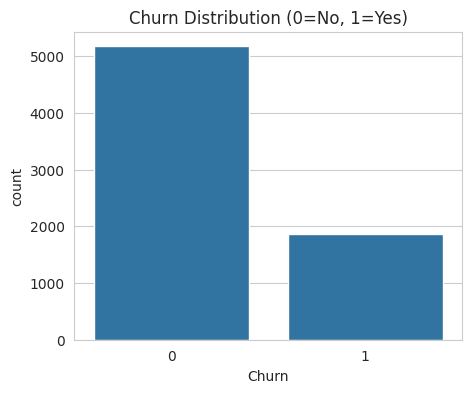

Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution (0=No, 1=Yes)')
plt.show()
print(df['Churn'].value_counts(normalize=True).round(4))

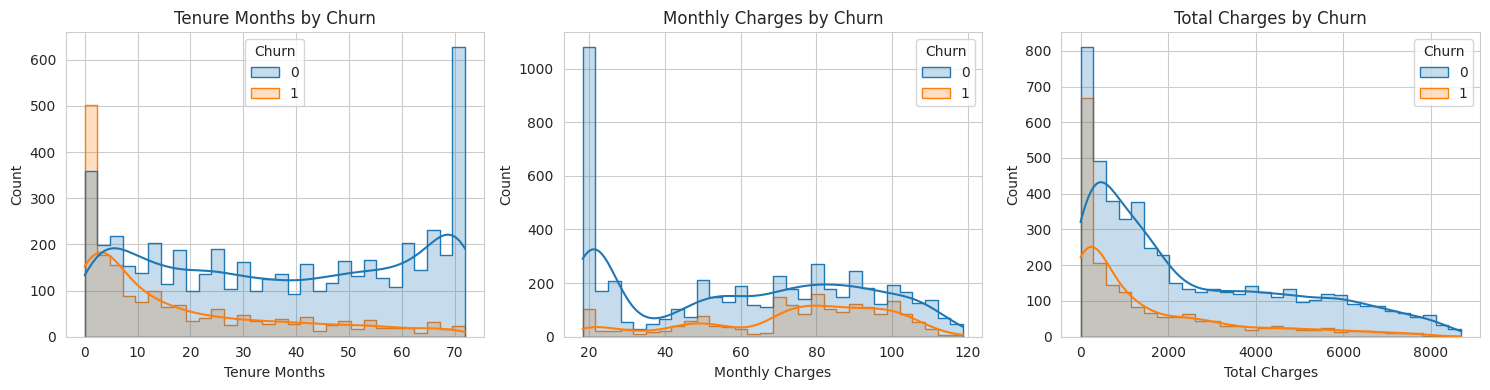

In [10]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, col in zip(axes, ['Tenure Months','Monthly Charges','Total Charges']):
    sns.histplot(data=df, x=col, hue='Churn', bins=30, kde=True, ax=ax, element='step')
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

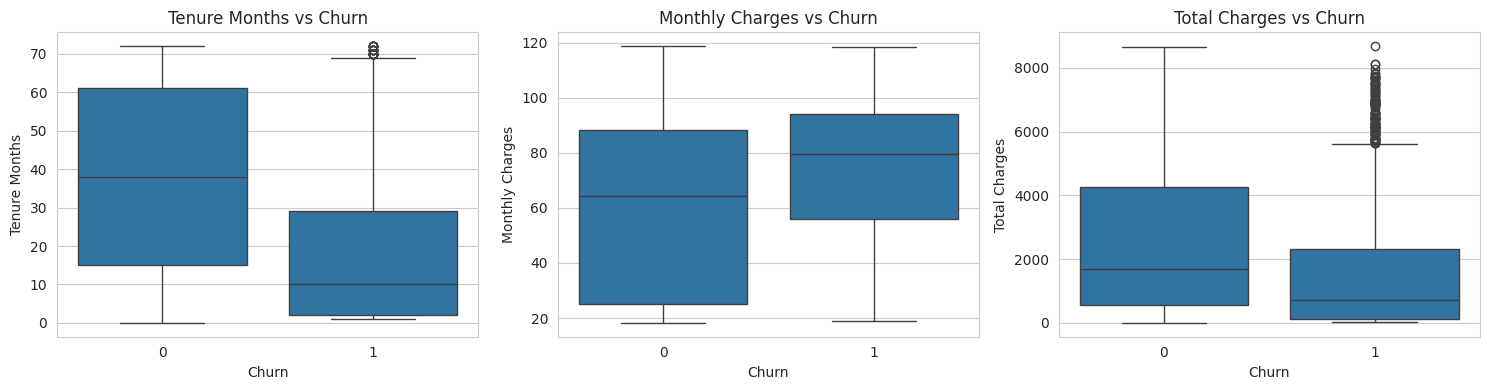

In [11]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, col in zip(axes, ['Tenure Months','Monthly Charges','Total Charges']):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax)
    ax.set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

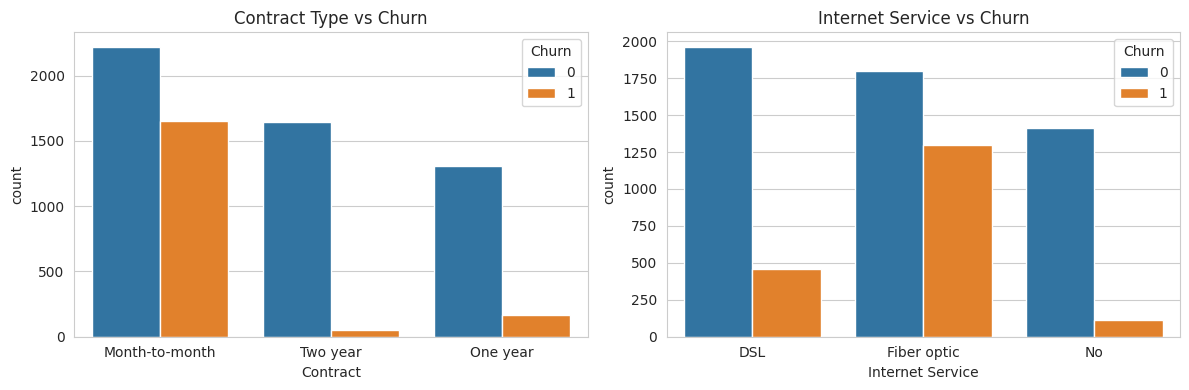

In [12]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Contract Type vs Churn')
sns.countplot(data=df, x='Internet Service', hue='Churn', ax=axes[1])
axes[1].set_title('Internet Service vs Churn')
plt.tight_layout()
plt.show()

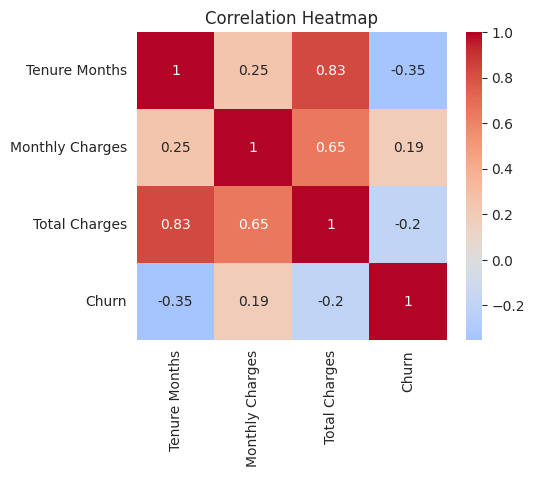

In [13]:
num_df = df[['Tenure Months','Monthly Charges','Total Charges','Churn']]
plt.figure(figsize=(5,4))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

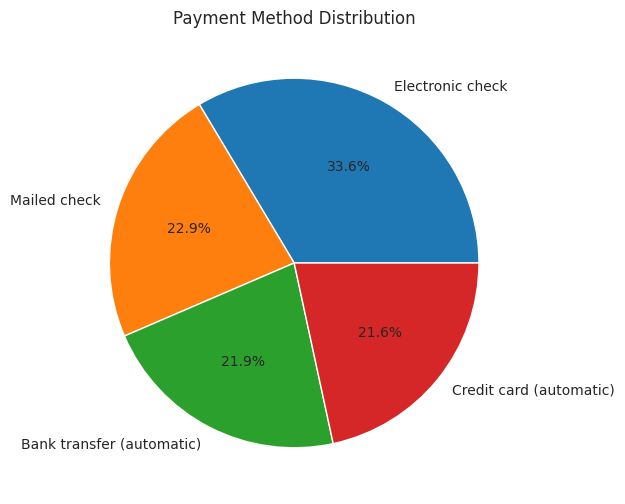

In [14]:
plt.figure(figsize=(6,6))
df['Payment Method'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()

### Chi-Square Tests (categorical features vs Churn)

$H_0$: the feature is independent of churn. Reject $H_0$ if p < 0.05.

In [15]:
cat_test_cols = ['Gender','Senior Citizen','Partner','Dependents','Phone Service',
            'Multiple Lines','Internet Service','Online Security','Online Backup',
            'Device Protection','Tech Support','Streaming TV','Streaming Movies',
            'Contract','Paperless Billing','Payment Method']

chi_results = []
for c in cat_test_cols:
    ct = pd.crosstab(df[c], df['Churn'])
    chi2, p, dof, exp = chi2_contingency(ct)
    chi_results.append({'Feature': c, 'Chi2': round(chi2,2), 'p_value': round(p,4),
                         'Significant (p<0.05)': p < 0.05})

chi_df = pd.DataFrame(chi_results).sort_values('Chi2', ascending=False)
chi_df

,Feature,Chi2,p_value,Significant (p<0.05)
13,Contract,1184.60,0.0000,True
7,Online Security,850.00,0.0000,True
10,Tech Support,828.20,0.0000,True
6,Internet Service,732.31,0.0000,True
15,Payment Method,648.14,0.0000,True
8,Online Backup,601.81,0.0000,True
9,Device Protection,558.42,0.0000,True
3,Dependents,433.73,0.0000,True
12,Streaming Movies,375.66,0.0000,True
11,Streaming TV,374.20,0.0000,True


In [16]:
print("Point-biserial correlation with Churn (numeric features):")
df[['Tenure Months','Monthly Charges','Total Charges']].corrwith(df['Churn']).sort_values()

Point-biserial correlation with Churn (numeric features):


Tenure Months     -0.352229
Total Charges     -0.198324
Monthly Charges    0.193356
dtype: float64

**EDA takeaways:**
- Churn rate is ~26.5% — moderately imbalanced.
- Month-to-month contracts, fiber optic internet, and electronic check payment are strongly associated with higher churn.
- Longer tenure correlates with lower churn (r = -0.35), the strongest numeric signal.
- `Gender` and `Phone Service` show no significant association with churn (p > 0.05).

## 4. Feature Selection & Train/Test Split

We split **before** encoding/scaling to avoid data leakage, then one-hot encode multi-category
columns (fit on train, aligned onto test), and drop the two statistically insignificant features
identified above.

In [17]:
customer_id = df['CustomerID']
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(4), " Test churn rate:", y_test.mean().round(4))

Train: (5634, 19)  Test: (1409, 19)
Train churn rate: 0.2654  Test churn rate: 0.2654


In [18]:
binary_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
               'Phone Service', 'Paperless Billing']
multi_cat_cols = ['Multiple Lines', 'Internet Service', 'Online Security',
                  'Online Backup', 'Device Protection', 'Tech Support',
                  'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method']

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for c in binary_cols:
    X_train[c] = X_train[c].map(binary_map)
    X_test[c] = X_test[c].map(binary_map)

X_train_encoded = pd.get_dummies(X_train, columns=multi_cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=multi_cat_cols, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("Encoded train shape:", X_train_encoded.shape)

Encoded train shape: (5634, 30)


In [19]:
# Drop statistically insignificant features (Gender, Phone Service; p > 0.05)
drop_insignificant = ['Gender', 'Phone Service']
X_train_sel = X_train_encoded.drop(columns=drop_insignificant)
X_test_sel = X_test_encoded.drop(columns=drop_insignificant)
print("Final feature set:", X_train_sel.shape)
list(X_train_sel.columns)

Final feature set: (5634, 28)


['Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Paperless Billing',
 'Monthly Charges',
 'Total Charges',
 'Multiple Lines_No phone service',
 'Multiple Lines_Yes',
 'Internet Service_Fiber optic',
 'Internet Service_No',
 'Online Security_No internet service',
 'Online Security_Yes',
 'Online Backup_No internet service',
 'Online Backup_Yes',
 'Device Protection_No internet service',
 'Device Protection_Yes',
 'Tech Support_No internet service',
 'Tech Support_Yes',
 'Streaming TV_No internet service',
 'Streaming TV_Yes',
 'Streaming Movies_No internet service',
 'Streaming Movies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'Payment Method_Credit card (automatic)',
 'Payment Method_Electronic check',
 'Payment Method_Mailed check']

## 5. Model Building & Evaluation

Five classifiers are trained and compared: Logistic Regression, KNN, Gaussian Naive Bayes,
Decision Tree, and Random Forest. Features are standardized, and 5-fold stratified
cross-validation is used alongside held-out test metrics.

In [20]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_sel)
X_test_s = scaler.transform(X_test_sel)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=11),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
roc_data = {}
cms = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:,1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy')

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
                     'F1': f1, 'ROC-AUC': auc, 'CV Acc (mean)': cv_scores.mean(),
                     'CV Acc (std)': cv_scores.std()})
    roc_data[name] = roc_curve(y_test, proba)
    cms[name] = confusion_matrix(y_test, preds)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV Acc (mean),CV Acc (std)
4,Random Forest,0.808375,0.684397,0.516043,0.588415,0.852787,0.809374,0.013484
0,Logistic Regression,0.798439,0.634731,0.566845,0.598870,0.848697,0.812036,0.012297
3,Decision Tree,0.798439,0.633136,0.572193,0.601124,0.835630,0.793754,0.011170
2,Naive Bayes,0.687722,0.452991,0.850267,0.591078,0.816787,0.697906,0.008446
1,KNN,0.775018,0.578947,0.558824,0.568707,0.812925,0.791093,0.010084


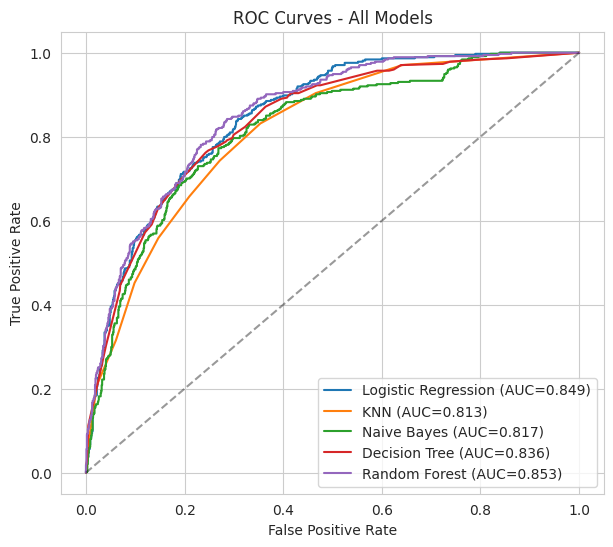

In [21]:
plt.figure(figsize=(7,6))
for name, (fpr, tpr, _) in roc_data.items():
    auc = results_df.loc[results_df['Model']==name, 'ROC-AUC'].values[0]
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.show()

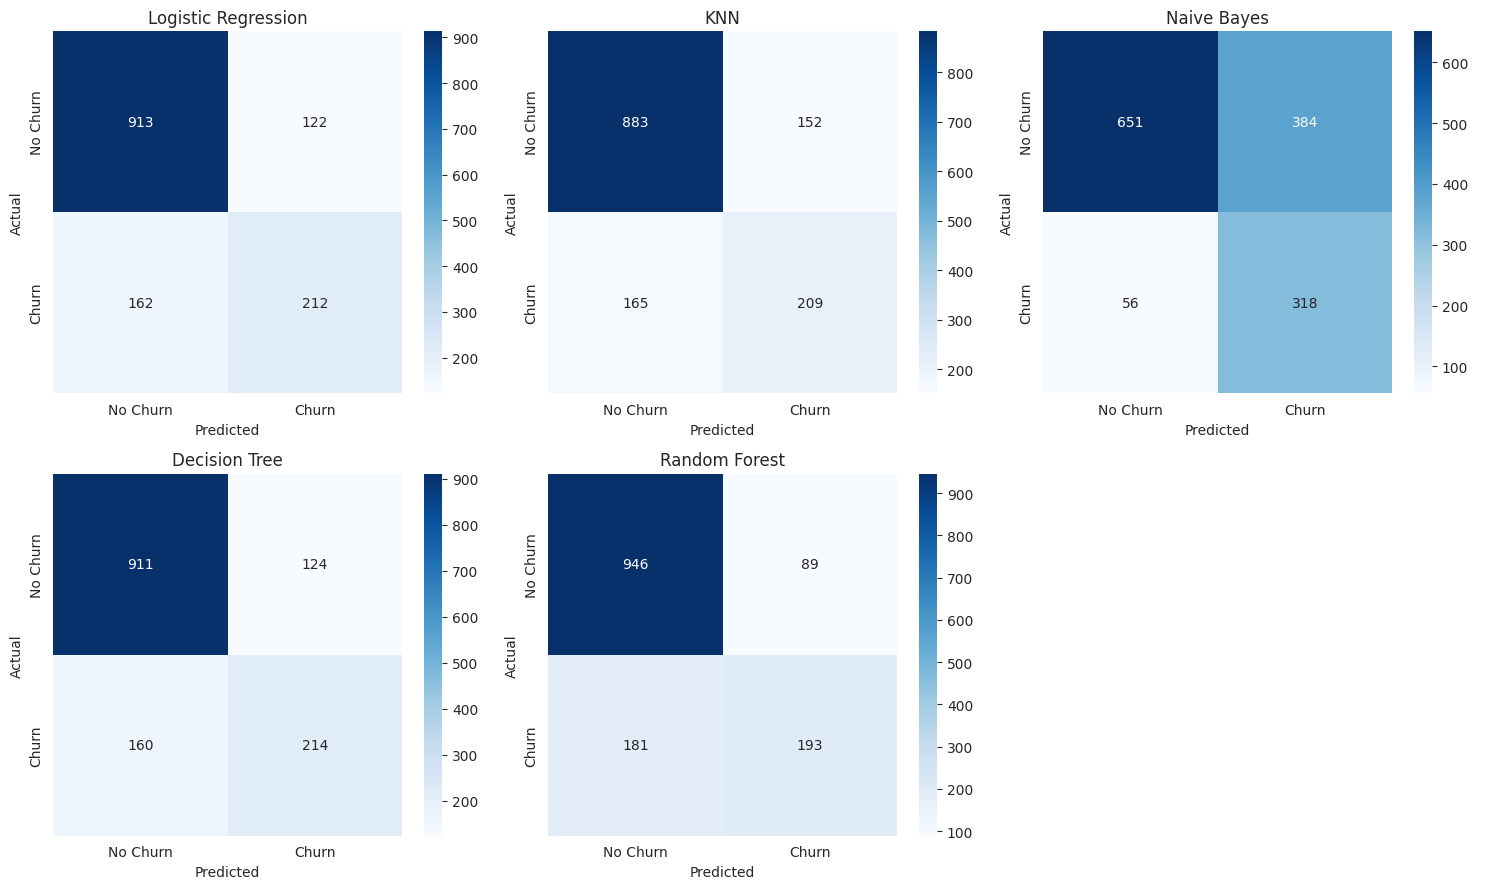

In [22]:
fig, axes = plt.subplots(2,3, figsize=(15,9))
axes = axes.flatten()
for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Model comparison notes:**
- **Random Forest** has the best ROC-AUC (0.853) and is selected as the final model.
- **Naive Bayes** has by far the best recall (0.85) despite lower accuracy — worth
  mentioning as a trade-off if the business priority is catching as many churners as possible
  over minimizing false alarms.

In [23]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best model by ROC-AUC: {best_model_name}")

joblib.dump(models[best_model_name], 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train_sel.columns), 'feature_columns.pkl')
print("Saved best_model.pkl, scaler.pkl, feature_columns.pkl for Streamlit deployment")

Best model by ROC-AUC: Random Forest
Saved best_model.pkl, scaler.pkl, feature_columns.pkl for Streamlit deployment
